#  Week12_Lab02_Mardonali_Fayzullayev_230423

# **RICE COUNTING USING BORDER EXTRACTION**

# **Step 1: Install required libraries**

In [1]:
!pip install opencv-python matplotlib numpy


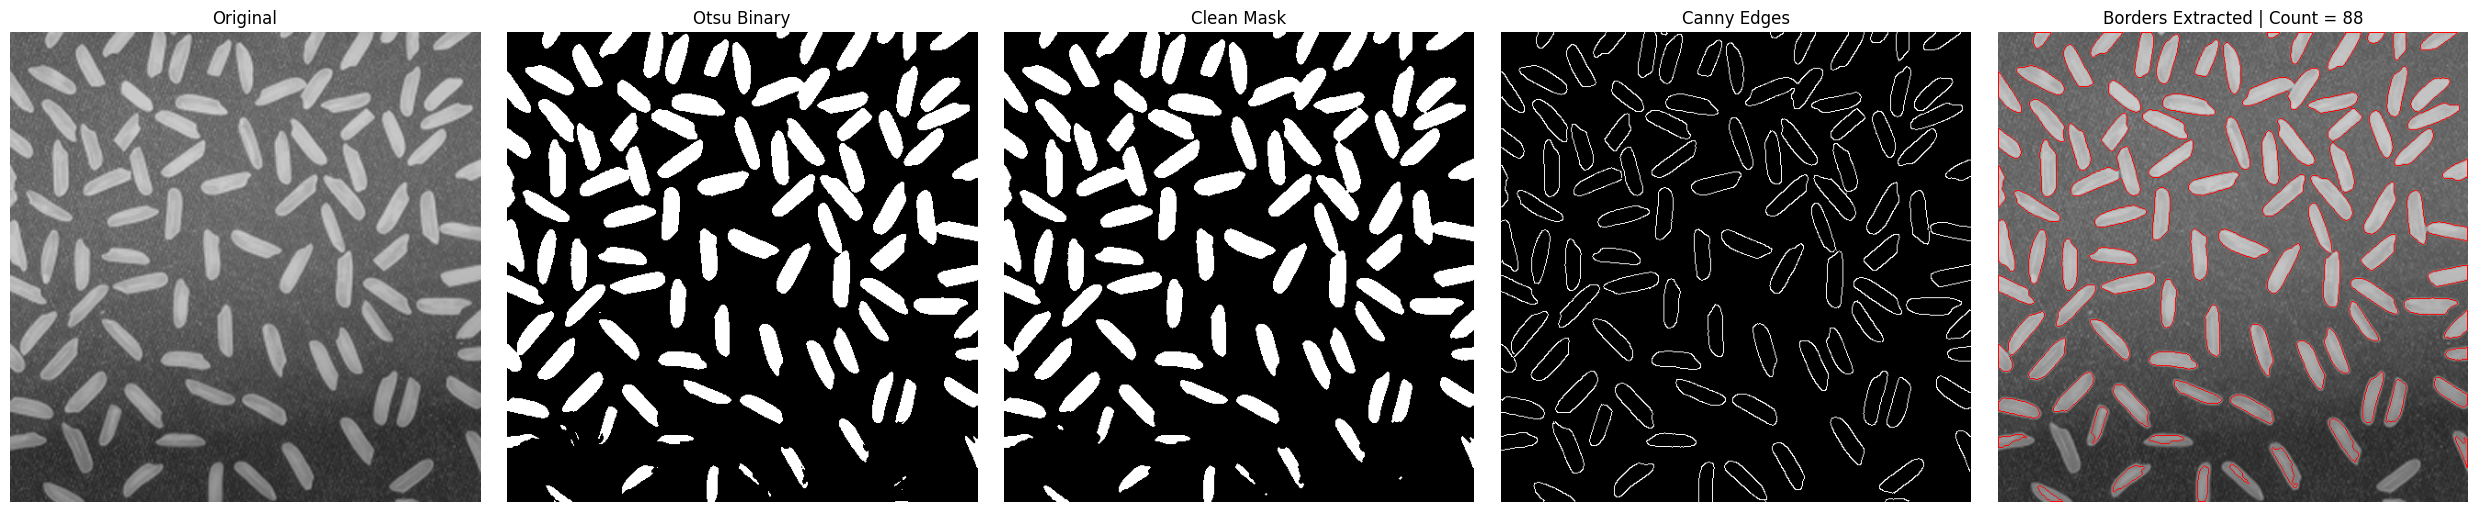

Estimated rice grains: 88


In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- 1) Load image ---
img_path = Path("sample_data/rice.png") # Corrected path
if not img_path.exists():
    raise FileNotFoundError(f"Image not found: {img_path.resolve()}")

image_bgr = cv2.imread(str(img_path))
if image_bgr is None:
    raise ValueError("Could not read rice.png")

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

# --- 2) Preprocess + threshold ---
blur = cv2.GaussianBlur(gray, (5, 5), 0)
_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
edges = cv2.Canny(blur, 50, 150) # Added Canny edge detection

# If background appears white and rice dark, invert so rice becomes white objects
if np.mean(binary) > 127:
    binary = cv2.bitwise_not(binary)

# --- 3) Clean noise and separate touching grains (morphology) ---
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
clean = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)
clean = cv2.morphologyEx(clean, cv2.MORPH_CLOSE, kernel, iterations=1)

# --- 4) Border extraction with contours ---
contours, _ = cv2.findContours(clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Filter tiny blobs (noise) by area
min_area = 20
rice_contours = [c for c in contours if cv2.contourArea(c) >= min_area]
rice_count = len(rice_contours)

# Draw extracted borders
outlined = image_rgb.copy()
cv2.drawContours(outlined, rice_contours, -1, (255, 0, 0), 1)

# --- 5) Show results ---
fig, axes = plt.subplots(1, 5, figsize=(25, 5)) # Changed to 5 subplots
axes[0].imshow(image_rgb)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(binary, cmap="gray")
axes[1].set_title("Otsu Binary")
axes[1].axis("off")

axes[2].imshow(clean, cmap="gray")
axes[2].set_title("Clean Mask")
axes[2].axis("off")

axes[3].imshow(edges, cmap="gray") # Added Canny edges plot
axes[3].set_title("Canny Edges")
axes[3].axis("off")

axes[4].imshow(outlined)
axes[4].set_title(f"Borders Extracted | Count = {rice_count}")
axes[4].axis("off")

plt.tight_layout()
plt.show()

print(f"Estimated rice grains: {rice_count}")

## Report

This notebook demonstrates a method for counting rice grains in an image using computer vision techniques.

**Steps Performed:**

1.  **Image Loading:** The `rice.png` image was loaded into the notebook.
2.  **Preprocessing & Thresholding:**
    *   The image was converted to grayscale.
    *   Gaussian blur was applied to reduce noise.
    *   Otsu's method was used for binary thresholding to separate rice grains from the background.
    *   Canny edge detection was applied to identify edges within the blurred image.
3.  **Morphological Operations:**
    *   Opening and closing operations were performed to clean noise and separate touching grains.
4.  **Border Extraction & Counting:**
    *   External contours were found from the cleaned binary image.
    *   Tiny blobs (noise) were filtered out based on a minimum area threshold (20 pixels).
    *   The remaining contours were counted as individual rice grains.
    *   The borders of the detected rice grains were drawn on the original image.
5.  **Visualization:** The following images were displayed:
    *   Original image
    *   Otsu Binary image
    *   Clean Mask (after morphological operations)
    *   Canny Edges image
    *   Outlined image with detected borders and the final count.

**Result:**

Based on the applied image processing steps, **88** rice grains were estimated in the provided image.